This script calculates and plots the zonal winds in the atmosphere

## **0. Importing packages and functions**

In [20]:
from ua_functions import*

# **A. NorESM2-LM**

## **1. Getting the ua data from NIRD**

In [3]:
experiments = ['piControl', 'abrupt-4xCO2']

ua_exp_noresm2_piControl = []
ua_exp_noresm2_x4CO2 = []

for experiment in experiments:
            
    folder_path = f'/projects/NS9034K/CMIP6/CMIP/NCC/NorESM2-LM/{experiment}/r1i1p1f1/Amon/ua/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 500*12))

    yearly_ua = yearly_avg(ds['ua'])

    if experiment == 'piControl':
        ua_exp_noresm2_piControl = yearly_ua
    elif experiment == 'abrupt-4xCO2':
        ua_exp_noresm2_x4CO2 = yearly_ua

## **2. Getting the zonal average for the time slices of interest**

In [4]:
ua_noresm2_zonal_0_30 = (ua_exp_noresm2_x4CO2.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')
ua_noresm2_zonal_120_150 = (ua_exp_noresm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon')
ua_noresm2_zonal_470_500 = (ua_exp_noresm2_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon')

ua_noresm2_zonal_piControl = (ua_exp_noresm2_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')

# turning zero to nan

ua_noresm2_zonal_0_30 = ua_noresm2_zonal_0_30.where(ua_noresm2_zonal_0_30 !=0)
ua_noresm2_zonal_120_150 = ua_noresm2_zonal_120_150.where(ua_noresm2_zonal_120_150 !=0)
ua_noresm2_zonal_470_500 = ua_noresm2_zonal_470_500.where(ua_noresm2_zonal_470_500 !=0)
ua_noresm2_zonal_piControl = ua_noresm2_zonal_piControl.where(ua_noresm2_zonal_piControl !=0)

# **B. IPSL-CM6A-LR**

## **1. Getting the ua data from NIRD**

In [5]:
experiments = ['piControl', 'abrupt-4xCO2']

ua_exp_ipsl_piControl = []
ua_exp_ipsl_x4CO2 = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/IPSL/IPSL-CM6A-LR/{experiment}/r1i1p1f1/Amon/ua/gr/latest/'
    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 900*12))
    ds['time'] = to_cftime(ds['time'].values)

    yearly_ua = yearly_avg(ds['ua'])

    if experiment == 'piControl':
        ua_exp_ipsl_piControl = yearly_ua
    elif experiment == 'abrupt-4xCO2':
        ua_exp_ipsl_x4CO2 = yearly_ua

## **2. Getting the zonal average for the time slices of interest**

In [6]:
ua_ipsl_zonal_0_30 = (ua_exp_ipsl_x4CO2.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')
ua_ipsl_zonal_120_150 = (ua_exp_ipsl_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon')
ua_ipsl_zonal_470_500 = (ua_exp_ipsl_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon')
ua_ipsl_zonal_870_900 = (ua_exp_ipsl_x4CO2.isel(year = slice(870,900))).mean(dim='year').mean(dim='lon')

ua_ipsl_zonal_piControl = (ua_exp_ipsl_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')

# turning zero to nan

ua_ipsl_zonal_0_30 = ua_ipsl_zonal_0_30.where(ua_ipsl_zonal_0_30 !=0)
ua_ipsl_zonal_120_150 = ua_ipsl_zonal_120_150.where(ua_ipsl_zonal_120_150 !=0)
ua_ipsl_zonal_470_500 = ua_ipsl_zonal_470_500.where(ua_ipsl_zonal_470_500 !=0)
ua_ipsl_zonal_870_900 = ua_ipsl_zonal_870_900.where(ua_ipsl_zonal_piControl !=0)

ua_ipsl_zonal_piControl = ua_ipsl_zonal_piControl.where(ua_ipsl_zonal_piControl !=0)

# **C. CESM2**

## **1. Getting the ua data from NIRD**

In [7]:
experiments = ['piControl', 'abrupt-4xCO2']

ua_exp_cesm2_piControl = []
ua_exp_cesm2_x4CO2 = []

for experiment in experiments:

    folder_path = f'/datalake/NS9560K/ESGF/CMIP6/CMIP/NCAR/CESM2/{experiment}/r1i1p1f1/Amon/ua/gn/latest/'

    file_names = sorted(os.listdir(folder_path))
    
    datasets = [xr.open_dataset(os.path.join(folder_path, file_name), chunks={'time': 10}) for file_name in file_names if file_name.endswith('.nc')]

    # --- Add extra file for abrupt-4xCO2 ---
    if experiment == 'abrupt-4xCO2':
        extra_file = '/datalake/NS9560K/ESGF/rawdata/model/chrikap/ua_Amon_CESM2_abrupt-4xCO2_r1i1p1f1_gn_000101-015012.nc'
        extra_ds = xr.open_dataset(extra_file, chunks={'time': 10})
        # Prepend it
        datasets = [extra_ds] + datasets
        
    
    # Merge all the datasets in the list along the same dimension
    merged_datasets = xr.concat(datasets, dim='time')
    ds = merged_datasets.isel(time=slice(0, 999*12))

    yearly_ua = yearly_avg(ds['ua'])
    
    if experiment == 'piControl':
        ua_exp_cesm2_piControl = yearly_ua
    elif experiment == 'abrupt-4xCO2':
        ua_exp_cesm2_x4CO2 = yearly_ua

## **2. Getting the zonal average for the time slices of interest**

In [11]:
ua_cesm2_zonal_120_150 = (ua_exp_cesm2_x4CO2.isel(year = slice(120, 150))).mean(dim='year').mean(dim='lon')
ua_cesm2_zonal_470_500 = (ua_exp_cesm2_x4CO2.isel(year = slice(470,500))).mean(dim='year').mean(dim='lon')
ua_cesm2_zonal_870_900 = (ua_exp_cesm2_x4CO2.isel(year = slice(870,900))).mean(dim='year').mean(dim='lon')
ua_cesm2_zonal_970_999 = (ua_exp_cesm2_x4CO2.isel(year = slice(970,999))).mean(dim='year').mean(dim='lon')

ua_cesm2_zonal_piControl = (ua_exp_cesm2_piControl.isel(year = slice(0, 30))).mean(dim='year').mean(dim='lon')

# turning zero to nan

ua_cesm2_zonal_120_150 = ua_cesm2_zonal_120_150.where(ua_cesm2_zonal_120_150 !=0)
ua_cesm2_zonal_470_500 = ua_cesm2_zonal_470_500.where(ua_cesm2_zonal_470_500 !=0)
ua_cesm2_zonal_870_900 = ua_cesm2_zonal_870_900.where(ua_cesm2_zonal_piControl !=0)
ua_cesm2_zonal_970_999 = ua_cesm2_zonal_970_999.where(ua_cesm2_zonal_piControl !=0)

ua_cesm2_zonal_piControl = ua_cesm2_zonal_piControl.where(ua_cesm2_zonal_piControl !=0)

# **D. Plotting**

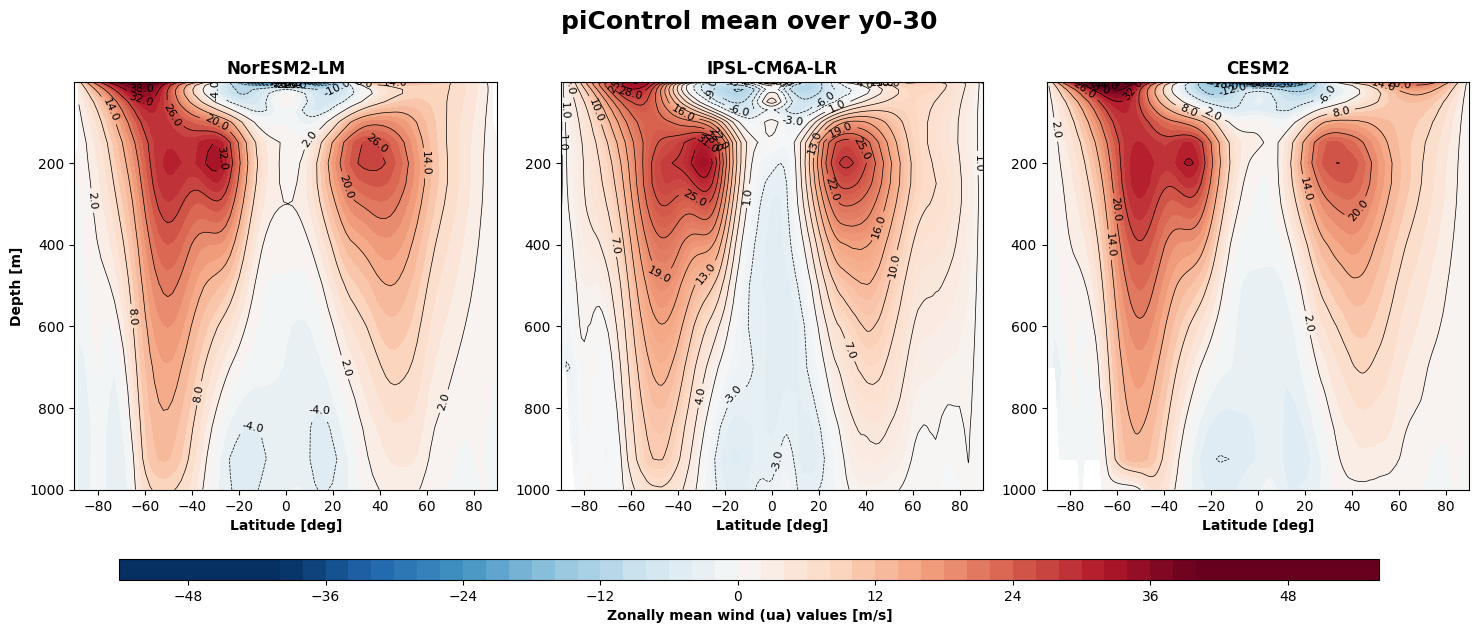

In [17]:
data_piControl_list = [ua_noresm2_zonal_piControl, ua_ipsl_zonal_piControl, ua_cesm2_zonal_piControl]
titles = ["NorESM2-LM", "IPSL-CM6A-LR", "CESM2"]

fig = plt.figure(figsize=(18, 6))
gs = fig.add_gridspec(nrows=1, ncols=3, width_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(0, 3):

    if titles[i]== "NorESM2-LM":        

        lat = ua_noresm2_zonal_piControl.lat
        lev = ua_noresm2_zonal_piControl.plev/100 

    elif titles[i]== "IPSL-CM6A-LR":        

        lat = ua_ipsl_zonal_piControl.lat
        lev = ua_ipsl_zonal_piControl.plev/100 

    else:
        lat = ua_cesm2_zonal_piControl.lat
        lev = ua_cesm2_zonal_piControl.plev/100  
        
    data = data_piControl_list[i]

    #print(data)

    # Plot
    ax = fig.add_subplot(gs[0, i])

    im_pi = ax.contourf(
        lat, lev,
        data,
        levels=60,
        cmap="RdBu_r",
        vmin=-40, vmax=40
    )

    levels = im_pi.levels
    neg_levels = levels[levels < 0]
    pos_levels = levels[levels > 0]

    # Negative contours (dashed)
    pi_neg = ax.contour(lat, lev,
        (data),
        levels=neg_levels[::3],
        colors='k',
        linestyles='dashed',
        linewidths=0.5
    )
    
    # Positive contours (solid)
    pi_pos = ax.contour(lat, lev,
        (data),
        levels=pos_levels[::3],
        colors='k',
        linestyles='solid',
        linewidths=0.5
    )
    ax.set_title(titles[i], fontweight='bold')
    ax.invert_yaxis()
    
    if i == 0:
        ax.set_ylabel("Depth [m]", fontweight="bold")

    # Add x-label to all panels
    ax.set_xlabel("Latitude [deg]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

# ---- Horizontal colorbar spanning all panels ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.035])  # [left, bottom, width, height]
cbar = fig.colorbar(im_pi, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Zonally mean wind (ua) values [m/s]", fontweight='bold')

fig.suptitle("piControl mean over y0-30", fontsize=18, weight='bold', y=1)
plt.subplots_adjust(top=0.88, bottom=0.20, wspace=0.15)

plt.show()

In [13]:
diff_noresm2_120_150 = (ua_noresm2_zonal_120_150 - ua_noresm2_zonal_piControl).values
diff_noresm2_470_500 = (ua_noresm2_zonal_470_500 - ua_noresm2_zonal_piControl).values

In [14]:
diff_ipsl_120_150 = (ua_ipsl_zonal_120_150 - ua_ipsl_zonal_piControl).values
diff_ipsl_470_500 = (ua_ipsl_zonal_470_500 - ua_ipsl_zonal_piControl).values
diff_ipsl_870_900 = (ua_ipsl_zonal_870_900 - ua_ipsl_zonal_piControl).values

In [15]:
diff_cesm2_120_150 = (ua_cesm2_zonal_120_150 - ua_cesm2_zonal_piControl).values
diff_cesm2_470_500 = (ua_cesm2_zonal_470_500 - ua_cesm2_zonal_piControl).values
diff_cesm2_870_900 = (ua_cesm2_zonal_870_900 - ua_cesm2_zonal_piControl).values
diff_cesm2_970_999 = (ua_cesm2_zonal_970_999 - ua_cesm2_zonal_piControl).values

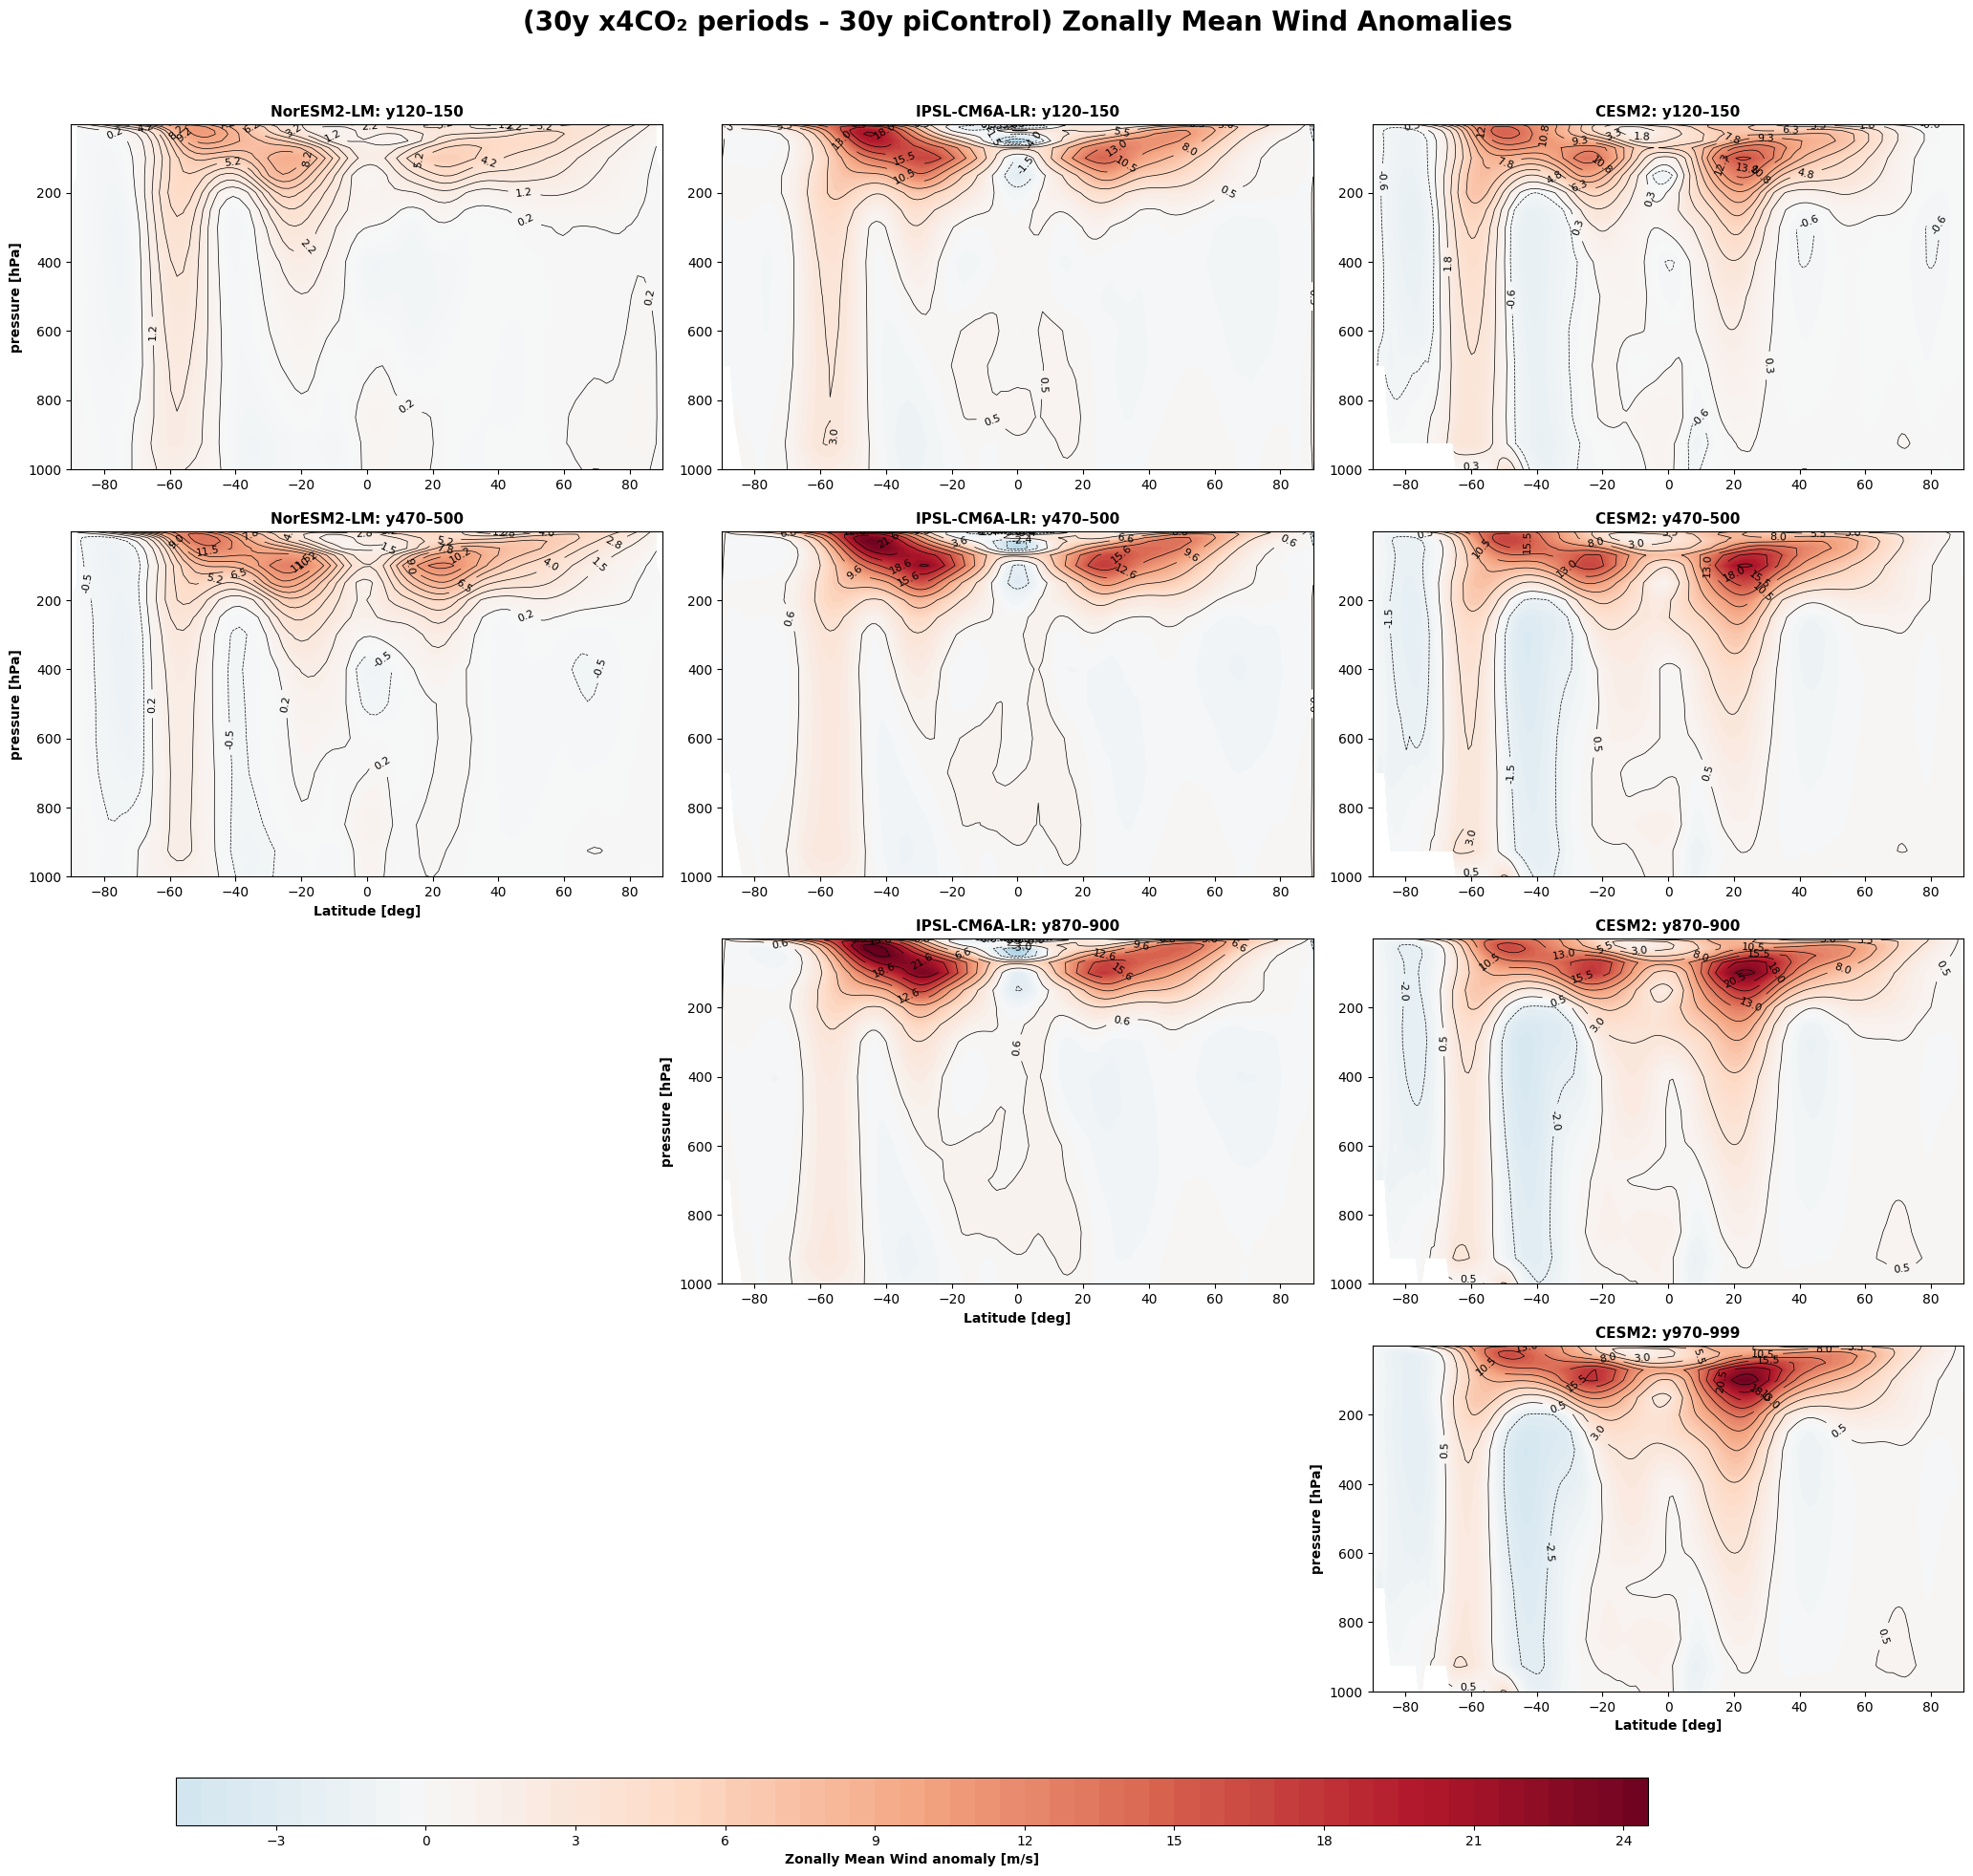

In [35]:
# ---- DATASETS ----
noresm_datasets = [
    (diff_noresm2_120_150,  "NorESM2-LM: y120–150", "noresm2"),
    (diff_noresm2_470_500,  "NorESM2-LM: y470–500", "noresm2"),
]

ipsl_datasets = [
    (diff_ipsl_120_150, "IPSL-CM6A-LR: y120–150", "ipsl"),
    (diff_ipsl_470_500, "IPSL-CM6A-LR: y470–500", "ipsl"),
    (diff_ipsl_870_900, "IPSL-CM6A-LR: y870–900", "ipsl"),
]

cesm_datasets = [
    (diff_cesm2_120_150, "CESM2: y120–150", "cesm2"),
    (diff_cesm2_470_500, "CESM2: y470–500", "cesm2"),
    (diff_cesm2_870_900, "CESM2: y870–900", "cesm2"),
    (diff_cesm2_970_999, "CESM2: y970–999", "cesm2"),
]

all_groups = [noresm_datasets, ipsl_datasets, cesm_datasets]

# Count rows for each column
col_rows = [len(g) for g in all_groups]
max_rows = max(col_rows)


# ---- FIGURE ----
fig = plt.figure(figsize=(22, 20))
gs = fig.add_gridspec(
    nrows=max_rows, ncols=3,
    height_ratios=[1]*max_rows,
    width_ratios=[1, 1, 1]
)

cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")


# =====================================================================
# PLOTTING LOOP
# =====================================================================

for col, group in enumerate(all_groups):      # loop over 3 columns
    n_panels = len(group)

    # Column 0 (NorESM2) starts at the top
    if col == 0:
        offset = 0
    else:
        offset = (max_rows - n_panels) // 2     # center columns 2 & 3

    for k, (data_anom, panel_title, model) in enumerate(group):

        # ------------------------ LAT & LEVELS ------------------------
        if model == "noresm2":
            lat = ua_noresm2_zonal_piControl.lat
            lev = ua_noresm2_zonal_piControl.plev/100 

        elif model == "ipsl":
            lat = ua_ipsl_zonal_piControl.lat
            lev = ua_ipsl_zonal_piControl.plev/100 

        elif model == "cesm2":
            lat = ua_cesm2_zonal_piControl.lat
            lev = ua_cesm2_zonal_piControl.plev/100  

        # Position in grid (row, column)
        row = offset + k
        ax = fig.add_subplot(gs[row, col])

        # ------------------------ FILLED CONTOURS ------------------------
        im = ax.contourf(
            lat, lev, data_anom,
            levels=60, cmap="RdBu_r",
            vmin=-25, vmax=25
        )
        

        # ------------------------ LINE CONTOURS ------------------------
        levels = im.levels
        neg_levels = levels[levels < 0]
        pos_levels = levels[levels > 0]

        anom_neg = ax.contour(lat, lev, data_anom,
                              levels=neg_levels[::5],
                              colors='k', linestyles='dashed', linewidths=0.5)
        anom_pos = ax.contour(lat, lev, data_anom,
                              levels=pos_levels[::5],
                              colors='k', linestyles='solid', linewidths=0.5)

        ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
        ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

        # ------------------------ AXES ------------------------
        ax.invert_yaxis()
        ax.set_title(panel_title, fontsize=11, fontweight='bold')

        # Left column gets y-label
        if col == 0 or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_ylabel("pressure [hPa]", fontweight="bold")
        
        # X-label only on the bottom panel of each column
        if (col == 0 and row == 1) or (col == 1 and row == 2) or (col == 2 and row == 3):
            ax.set_xlabel("Latitude [deg]", fontweight="bold")
        
# =====================================================================
# SHARED COLORBAR
# =====================================================================

cbar_ax = fig.add_axes([0.10, 0.03, 0.7, 0.025])
cbar = fig.colorbar(im, cax=cbar_ax, orientation='horizontal')
cbar.set_label("Zonally Mean Wind anomaly [m/s]", fontweight='bold')


# =====================================================================
# FINISH
# =====================================================================

fig.suptitle(
    "(30y x4CO₂ periods - 30y piControl) Zonally Mean Wind Anomalies",
    fontsize=20, weight='bold'
)

plt.subplots_adjust(
    left=0.05, right=0.95,
    top=0.92, bottom=0.10,
    wspace=0.10, hspace=0.18
)

plt.show()

In [18]:
data_piControl_list = [
    ua_noresm2_zonal_piControl.values,
    ua_ipsl_zonal_piControl.values,
    ua_cesm2_zonal_piControl.values
]

data_anom_list = [
    diff_noresm2_470_500,
    diff_ipsl_470_500,
    diff_cesm2_470_500
]

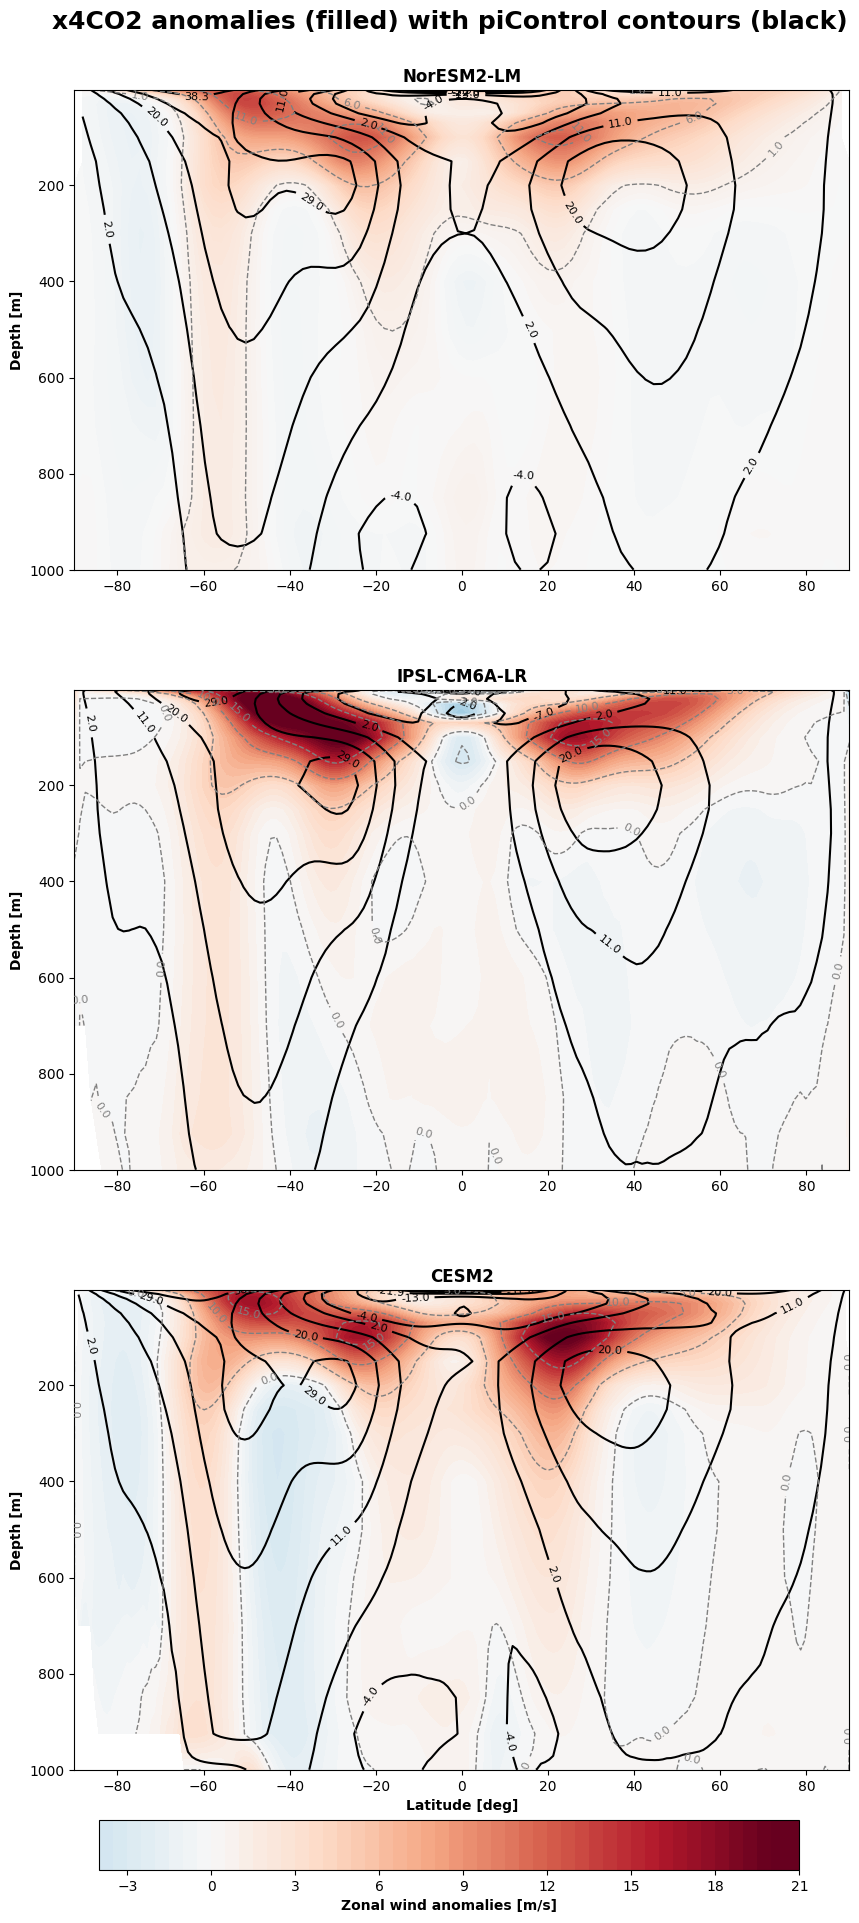

In [41]:
fig = plt.figure(figsize=(10, 20))
gs = fig.add_gridspec(nrows=3, ncols=1, height_ratios=[1, 1, 1])

# Copy and modify cmap
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="white")

for i in range(3):

    if titles[i]== "NorESM2-LM":        

        lat = ua_noresm2_zonal_piControl.lat
        lev = ua_noresm2_zonal_piControl.plev/100 

    elif titles[i]== "IPSL-CM6A-LR":        

        lat = ua_ipsl_zonal_piControl.lat
        lev = ua_ipsl_zonal_piControl.plev/100 

    else:
        lat = ua_cesm2_zonal_piControl.lat
        lev = ua_cesm2_zonal_piControl.plev/100  

    data_picontrol = data_piControl_list[i]
    data_anom = data_anom_list[i]

    target_levels_pi = np.arange(-40, 40, 3)
    target_levels_anom = np.arange(-20, 20)

    ax = fig.add_subplot(gs[i, 0])

    levels_pi = np.unique(nearest_levels(data_picontrol, target_levels_pi))
    levels_anom = np.unique(nearest_levels(data_anom, target_levels_anom))
    
    neg_levels_pi = levels_pi[levels_pi < 0]
    pos_levels_pi = levels_pi[levels_pi > 0]

    # ---- Line contours: piControl (black) ----
    pi_neg = ax.contour(
        lat, lev,
        data_picontrol,
        levels=neg_levels_pi[::3],
        colors="k",
        linestyles="solid",
        linewidths=1.5
    )

    pi_pos = ax.contour(
        lat, lev,
        data_picontrol,
        levels=pos_levels_pi[::3],
        colors="k",
        linestyles="solid",
        linewidths=1.5
    )

    neg_levels_anom = levels_anom[levels_anom < 0]
    pos_levels_anom = levels_anom[levels_anom > 0]

    # ---- Filled contours: anom ----
    im_anom = ax.contourf(
        lat, lev,
        data_anom,
        levels=60,
        cmap="RdBu_r",
        vmin=-20, vmax=20
    )

    # ---- Line contours: anom (red) ----
    anom_neg = ax.contour(
        lat, lev,
        data_anom,
        levels=neg_levels_anom[::5],
        colors="grey",
        linestyles="dashed",
        linewidths=1
    )

    anom_pos = ax.contour(
        lat, lev,
        data_anom,
        levels=pos_levels_anom[::5],
        colors="grey",
        linestyles="dashed",
        linewidths=1
    )

    ax.set_title(titles[i], fontweight="bold")
    ax.invert_yaxis()

    ax.set_ylabel("Depth [m]", fontweight="bold")

    ax.clabel(pi_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(pi_pos, inline=True, fmt="%1.1f", fontsize=8)

    ax.clabel(anom_neg, inline=True, fmt="%1.1f", fontsize=8)
    ax.clabel(anom_pos, inline=True, fmt="%1.1f", fontsize=8)

ax.set_xlabel("Latitude [deg]", fontweight="bold")

# ---- Horizontal colorbar ----
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.025])
cbar = fig.colorbar(im_anom, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Zonal wind anomalies [m/s]", fontweight="bold")

fig.suptitle(
    "x4CO2 anomalies (filled) with piControl contours (black)",
    fontsize=18,
    weight="bold",
    y=0.98
)

plt.subplots_adjust(top=0.94, bottom=0.10, hspace=0.25)
plt.show()